### Life Expectancy Exploratory Analysis

**Imports**

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

**Load the dataset**

In [5]:
life_exp_df = pd.read_csv('/Users/ioanna/Documents/EPFL/Semester2/DataVisualization/BlueZones/data/life-expectancy.csv')
print("The Life Expectancy dataset contains", life_exp_df.shape[0], "rows and", life_exp_df.shape[1], "columns.")

life_exp_df.head()

The Life Expectancy dataset contains 21565 rows and 4 columns.


,Entity,Code,Year,Life expectancy
0,Afghanistan,AFG,1950,28.1563
1,Afghanistan,AFG,1951,28.5836
2,Afghanistan,AFG,1952,29.0138
3,Afghanistan,AFG,1953,29.4521
4,Afghanistan,AFG,1954,29.6975


In [6]:
life_exp_df = life_exp_df.dropna(subset=['Entity', 'Year', 'Life expectancy'])

print("After removing rows with missing values, the dataset contains", life_exp_df.shape[0], "rows and", life_exp_df.shape[1], "columns.")

After removing rows with missing values, the dataset contains 21565 rows and 4 columns.


The dataset does not contain any missing values in the `Entity`, `Year`, and `Life expectancy` columns, which are the ones that are necessary for our analysis. 

For our analysis, we will consider the timeframe from `1950–2023`, as this is the period for which data is available for all countries in the dataset. Although data exists for some countries prior to 1950, these records are not consistently available across all countries and are not continuous. Therefore, to ensure comparability and consistency in the analysis, years before 1950 will be excluded.

In [7]:
life_exp_df = life_exp_df[(life_exp_df['Year'] >= 1950) & (life_exp_df['Year'] <= 2023)]

life_exp_df["Life expectancy"].describe()

count    19314.000000
mean        63.706135
std         11.960593
min         10.989100
25%         55.909850
50%         66.273700
75%         72.709525
max         86.372400
Name: Life expectancy, dtype: float64

In [8]:
# Blue Zone Countries
blue_zone_countries = ['Italy', 'Greece', 'Japan', 'Costa Rica', 'United States']

blue_zone_df = life_exp_df[life_exp_df['Entity'].isin(blue_zone_countries)]

rest_countries_df = life_exp_df[~life_exp_df['Entity'].isin(blue_zone_countries)]

**LineChart of Life Expectancy:** It contains a line plot showing the life expectancy of the countries that contain Blue Zone regions and the average life expectancy of the remaining countries over time. 

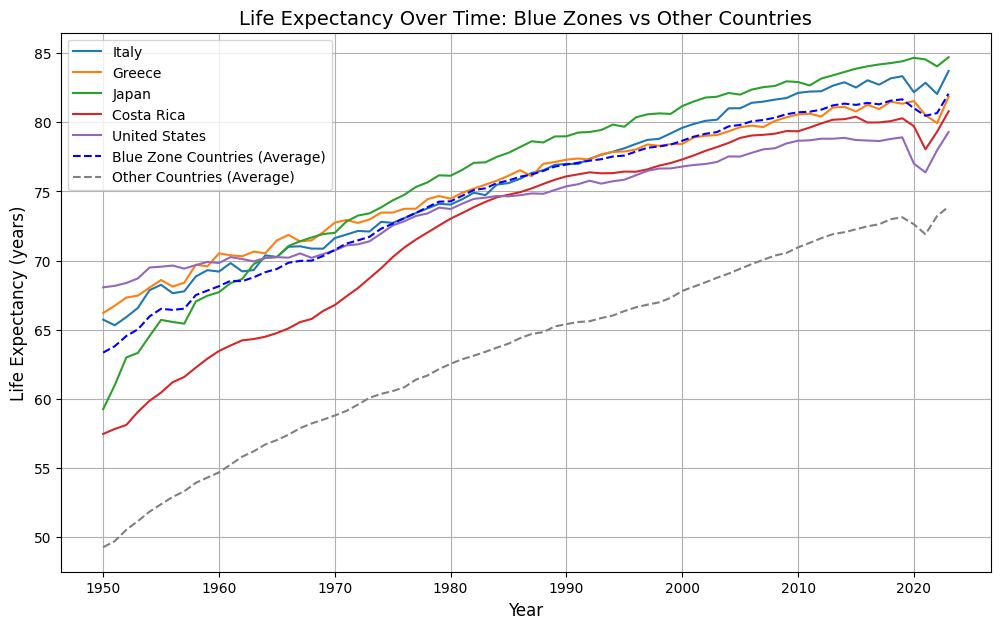

In [9]:
other_countries_avg_by_year = rest_countries_df.groupby('Year')['Life expectancy'].mean()
blue_zone_countries_avg_by_year = blue_zone_df.groupby('Year')['Life expectancy'].mean()

plt.figure(figsize=(12, 7))

for country in blue_zone_countries:
    country_data = blue_zone_df[blue_zone_df['Entity'] == country].sort_values('Year')
    plt.plot(country_data['Year'], country_data['Life expectancy'], label=country)

plt.plot(blue_zone_countries_avg_by_year.index, blue_zone_countries_avg_by_year.values, label='Blue Zone Countries (Average)', linestyle='--', color='blue')

plt.plot(other_countries_avg_by_year.index, other_countries_avg_by_year.values, label='Other Countries (Average)', linestyle='--', color='gray')

plt.xlabel('Year', fontsize=12)
plt.ylabel('Life Expectancy (years)', fontsize=12)
plt.title('Life Expectancy Over Time: Blue Zones vs Other Countries', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True)
plt.show()

In [10]:
print("The average life expectancy in Blue Zone countries in 2023 is:", blue_zone_df[blue_zone_df['Year'] == 2023]['Life expectancy'].mean())
print("The average life expectancy in other countries in 2023 is:", rest_countries_df[rest_countries_df['Year'] == 2023]['Life expectancy'].mean())

The average life expectancy in Blue Zone countries in 2023 is: 82.07772
The average life expectancy in other countries in 2023 is: 73.9067828125


As observed in the data, countries that contain Blue Zone regions tend to have higher life expectancy. In 2023, the average life expectancy in these countries was 82.07 years, compared to 73.9 years in countries without Blue Zones.

**Heatmap of life expectancy:** It contains a heatmap that shows the life expectancy of the top 30 countries in 2023 over time.

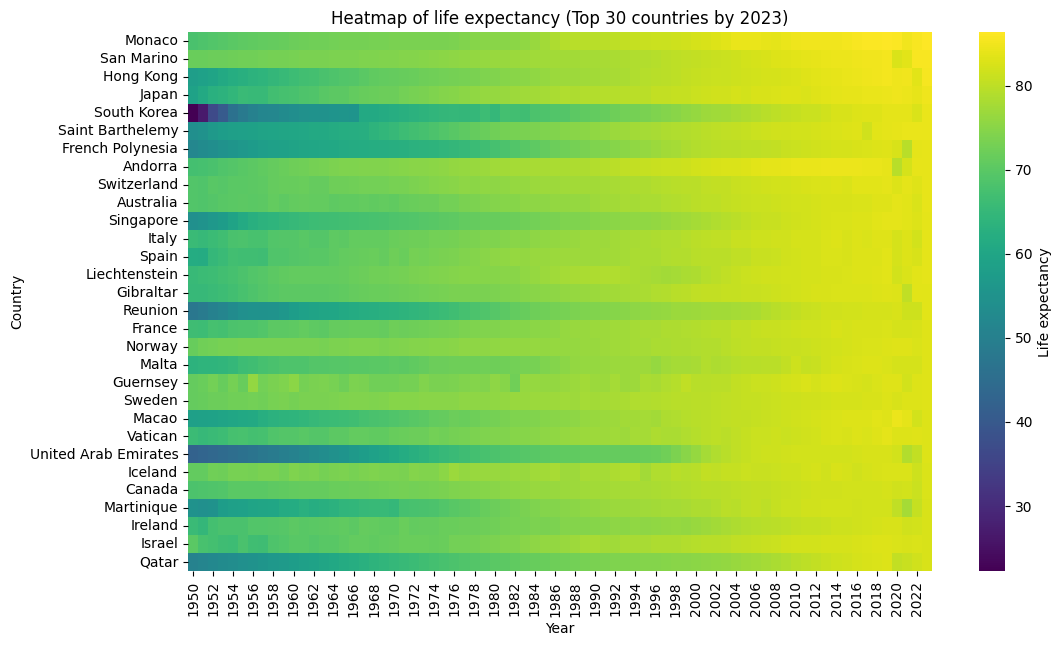

              Entity  Rank
9415           Japan   4.0
9179           Italy  12.0
7173          Greece  41.0
4052      Costa Rica  52.0
20511  United States  66.0


In [11]:
df_2023 = life_exp_df[life_exp_df['Year'] == 2023][['Entity', 'Life expectancy']]
top_30 = df_2023.sort_values('Life expectancy', ascending=False).head(30)['Entity']

heat_df = life_exp_df[life_exp_df['Entity'].isin(top_30)]
pivot = heat_df.pivot(index='Entity', columns='Year', values='Life expectancy')

pivot = pivot.loc[pivot[2023].sort_values(ascending=False).index]

plt.figure(figsize=(12, 7))
sns.heatmap(pivot, cmap='viridis', cbar_kws={'label': 'Life expectancy'})
plt.title('Heatmap of life expectancy (Top 30 countries by 2023)')
plt.xlabel('Year')
plt.ylabel('Country')
plt.show()


# The rank of all blue oznes in 2023
df_2023 = life_exp_df[life_exp_df['Year'] == 2023][['Entity', 'Life expectancy']]
df_2023['Rank'] = df_2023['Life expectancy'].rank(ascending=False)
blue_zone_ranks = df_2023[df_2023['Entity'].isin(blue_zone_countries)][['Entity', 'Rank']].sort_values('Rank')
print(blue_zone_ranks)

**Box plot distribution of life expectancy:** It contains box plots that compare the distribution of life expectancy in countries with Blue Zones and countries without Blue Zones in the years 1950, 1975, 2000, and 2023.

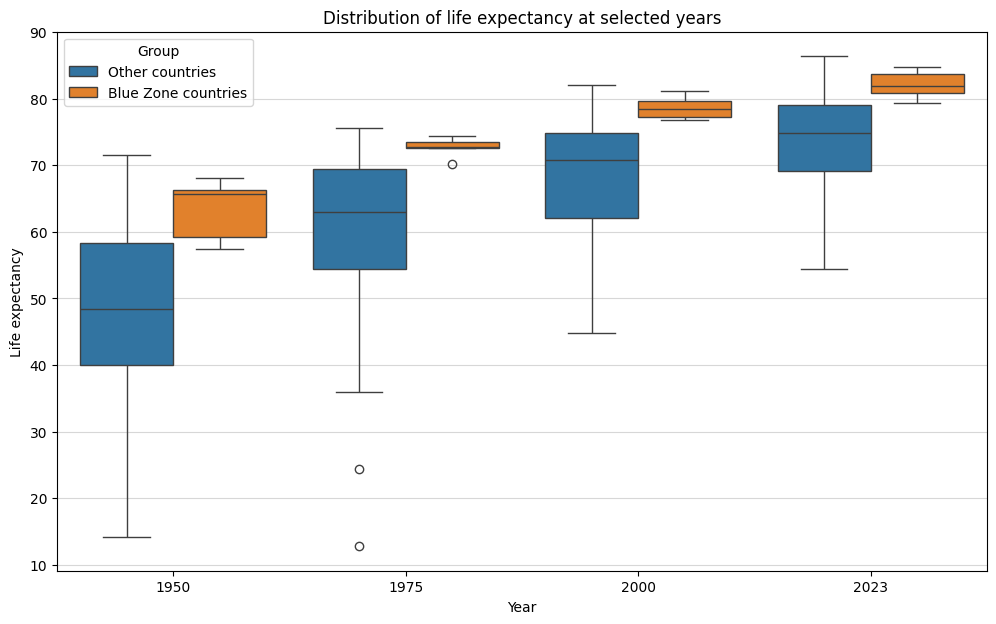

In [12]:
indicative_years = [1950, 1975, 2000, 2023]
distribution_df = life_exp_df[life_exp_df['Year'].isin(indicative_years)].copy()
distribution_df['Group'] = np.where(distribution_df['Entity'].isin(blue_zone_countries), 'Blue Zone countries', 'Other countries')

plt.figure(figsize=(12, 7))
sns.boxplot(data=distribution_df, x='Year', y='Life expectancy', hue='Group')
plt.title('Distribution of life expectancy at selected years')
plt.grid(axis='y', alpha=0.5)
plt.show()

**Bar chart of life expectancy:** It contains bar charts that shows the average life expectancy of the top and bottom 5 countries.

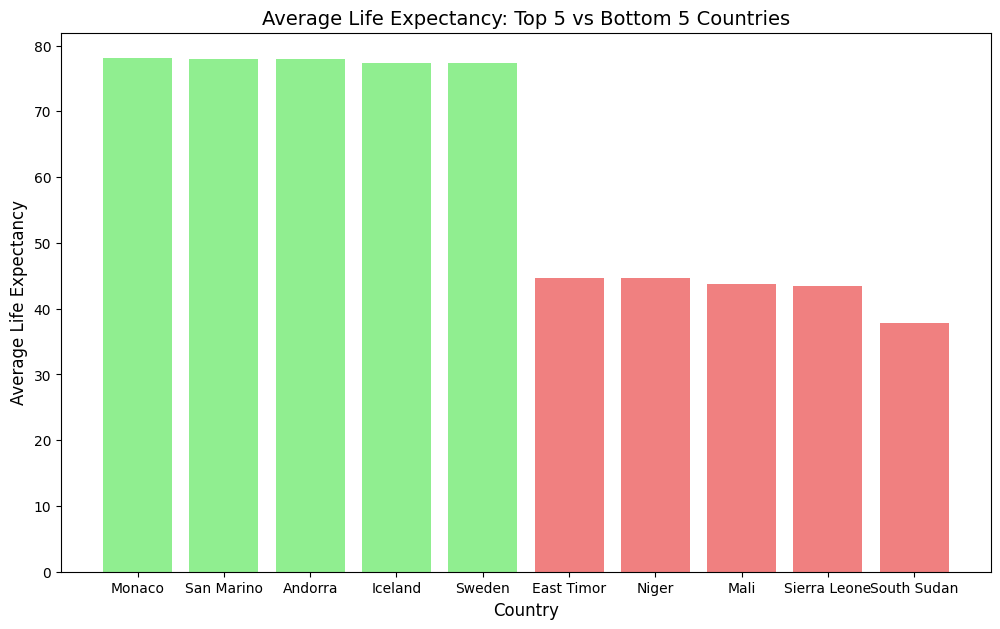

Italy is ranked 17 out of 261 in average life expectancy.
Greece is ranked 21 out of 261 in average life expectancy.
Japan is ranked 10 out of 261 in average life expectancy.
Costa Rica is ranked 49 out of 261 in average life expectancy.
United States is ranked 34 out of 261 in average life expectancy.


In [13]:
average_life_expectancy = life_exp_df.groupby('Entity')['Life expectancy'].mean().sort_values(ascending=False)

top_5_countries = average_life_expectancy.head(5)
bottom_5_countries = average_life_expectancy.tail(5)

combined = pd.concat([top_5_countries, bottom_5_countries])

colors = ['lightgreen']*5 + ['lightcoral']*5

plt.figure(figsize=(12, 7))
plt.bar(combined.index, combined.values, color=colors)

plt.xlabel('Country', fontsize=12)
plt.ylabel('Average Life Expectancy', fontsize=12)
plt.title('Average Life Expectancy: Top 5 vs Bottom 5 Countries', fontsize=14)
plt.show()

for country in blue_zone_countries:
    position = average_life_expectancy.index.get_loc(country) + 1
    print(f"{country} is ranked {position} out of {len(average_life_expectancy)} in average life expectancy.")